In [47]:
import pandas as pd
import matplotlib.pyplot as plt

raw = pd.read_csv('raw_data.csv', encoding='latin-1')
index = pd.read_csv('game_index.csv', encoding='latin-1')

print(raw.shape)
print(raw.head())
print(raw.columns.tolist())
print(index.columns.tolist())


(128, 18)
  game_id  observation_date obersvation_time  days_to_kickoff      team_1  \
0      G01        6/21/2026          2:00 PM              4.0         USA   
1      G02        6/21/2026          2:00 PM              4.0       Japan   
2      G03        6/21/2026          2:00 PM              4.0     Curacao   
3      G04        6/21/2026          2:00 PM              5.0      France   
4      G05        6/21/2026          2:00 PM              5.0  Cape Verde   

         team_2        round                 venue          city  capacity  \
0        Turkey  Group Stage   Los Angeles Stadium   Los Angeles   70492.0   
1        Sweden  Group Stage        Dallas Stadium        Dallas   70649.0   
2   Ivory Coast  Group Stage  Philadelphia Stadium  Philadelphia   68324.0   
3        Norway  Group Stage        Boston Stadium        Boston   64146.0   
4  Saudi Arabia  Group Stage       Houston Stadium       Houston   68777.0   

  host_nation  t1_fifa_rank  t2_fifa_rank  combined_rank  

In [48]:
raw['observation_date'] = pd.to_datetime(raw['observation_date'])

completed_games = ['G01', 'G02', 'G03', 'G04', 'G05', 'G06']
raw_completed = raw[raw['game_id '].isin(completed_games)]

print(raw_completed['game_id '].value_counts())

# Combine date and time into single datetime column
raw_completed = raw_completed.copy()
raw_completed['obs_datetime'] = pd.to_datetime(
    raw_completed['observation_date'].astype(str) + ' ' + 
    raw_completed['obersvation_time'].astype(str)
)

game_id 
G05    10
G06    10
G04     9
G01     8
G02     8
G03     8
Name: count, dtype: int64


/var/folders/2s/c_ncbyzd06s15k89762gfc780000gn/T/ipykernel_930/1094410564.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  raw_completed['obs_datetime'] = pd.to_datetime(


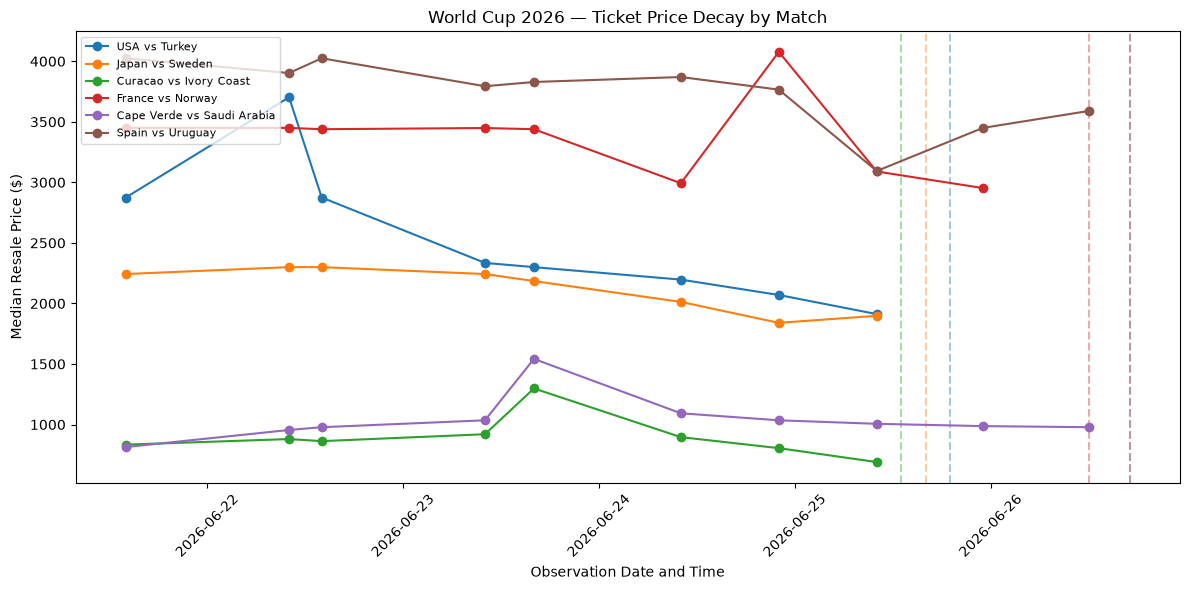

In [49]:
fig, ax = plt.subplots(figsize=(12, 6))

kickoff_times = {
    'G01': '2026-06-25 19:00',  # USA vs Turkey
    'G02': '2026-06-25 16:00',  # Japan vs Sweden
    'G03': '2026-06-25 13:00',  # Curacao vs Ivory Coast
    'G04': '2026-06-26 12:00',  # France vs Norway
    'G05': '2026-06-26 17:00',  # Cape Verde vs Saudi Arabia
    'G06': '2026-06-26 17:00',  # Spain vs Uruguay
}

for game_id, group in raw_completed.groupby('game_id '):
    label = f"{group['team_1'].iloc[0]} vs {group['team_2'].iloc[0]}"
    group = group.sort_values('obs_datetime', ascending=True)
    line, = ax.plot(group['obs_datetime'], group['median_price'], marker='o', label=label)

    if game_id in kickoff_times:
        kickoff = pd.to_datetime(kickoff_times[game_id])
        ax.axvline(x=kickoff, color=line.get_color(), linestyle='--', alpha=0.4)

ax.set_xlabel('Observation Date and Time')
ax.set_ylabel('Median Resale Price ($)')
ax.set_title('World Cup 2026 — Ticket Price Decay by Match')
ax.legend(loc='upper left', fontsize=8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()